Koncepcja zbiorów rozmytych została wprowadzona w 1965 roku przez Lotfiego Zadeh'a, Irańsko-amerykańskiego naukowca, który większość swojego naukowego życia spędził pracując na uniwersytecie w Berkeley.
Prof. Zadeh, jak jeszcze co najmniej kilku naukowców przed nim, zwrócił uwagę na trudny problem nieokreśloności w matematyce, informatyce, czy inżynierii (szczególnie automatycznym sterowaniu).

Zwróćmy uwagę, że my, ludzie, operujemy głównie pojęciami nieprecyzyjnymi, ogólnymi, które na wysokim poziomie abstrakcji sa bardzo przejrzyste i konkretne. Dajmy na to określenie "brzydka pogoda", "ciepła woda", "gorący talerz" wystarczająco precyzyjnie pozwalają nam na zdefiniowanie akcji, które należy podjąć (cieplej sie ubrać, uważać na możliwość oparzenia itd.).

Maszyny cyfrowe natomiast, od samego początku ich powstania, ze względu na ich obliczeniowy charakter, nie uwzględniają w swym standardowym interfejsice tego typu określeń. Owszem, dla określenia "ciepła woda" moglibyśmy zdefiniować przedział, powiedzmy pomiędzy 25, a 35 stopniami Celsjusza. A co z temperaturą na poziomie 24, lub 37? Czy to nie jest już ciepła woda według podanego przedziału? Niestety nie, ale czujemy "po ludzku", intuicyjnie, iż można je jeszcze do tej definicji podciągnąć.

Rozwiązanie, które zaproponował prof. Zadeh musiało być "obliczeniowe". Chciał, aby implementacja określeń nieprecyzyjnych mogła być zrealizowana za pomocą komputera i stworzyć swoistą wspólną przestrzeń reprezentacji wiedzy, która z jednej strony jest zrozumiała i intuicyjna dla człowieka, a z drugiej obliczalna z użyciem kmputera oraz nie była ograniczona do prostych przedziałów wartości, które, jak widać w zaproponownym przykładzie, prowadzą do dylematów.

Profesor Zadeh, kierując się matematyczną formą zbioru, zaproponował ideę zbioru rozmytego, który w przeciwieństwie do tego klasycznego, pozwala na **częściową przynależność** elementów.
  

Najprościej zobaczyć to na przykładzie. Najpierw użyjmy języka Python, aby narysować wykres funkcji charakterystycznej przykładowego zbioru A. Uruchom poniższy przykład:



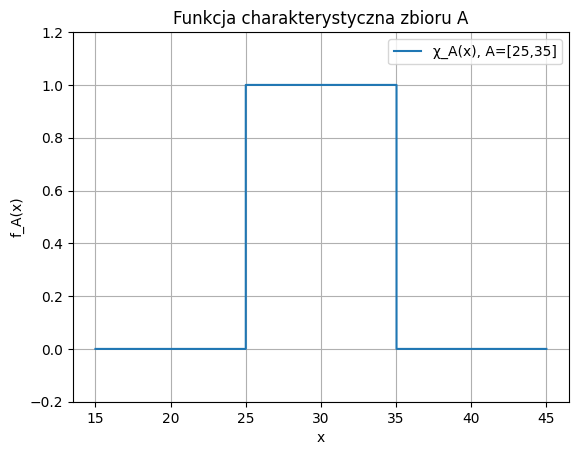

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Dziedzina
x = np.linspace(15, 45, 1000)

# Zbiór A = [25, 35]
A_start, A_end = 25, 35
chi_A = np.where((x >= A_start) & (x <= A_end), 1, 0)

# Rysowanie
plt.plot(x, chi_A, drawstyle="steps-post", label="χ_A(x), A=[25,35]")
plt.ylim(-0.2, 1.2)  # ograniczenie osi Y
plt.xlabel("x")
plt.ylabel("f_A(x)")
plt.title("Funkcja charakterystyczna zbioru A")
plt.grid(True)
plt.legend()
plt.show()

Wykres przypomina trochę to, co znamy ze szkoły podstawowej, czyli definicję prostego zbioru. Jak widać, funkcja charakterystyczna przyjmuje wartości 0 lub 1, w zalezności od tego czy element na osi X, odpowiednio, nie przynależy lub przynależy do zbiuru. W tym wypadku zbiór zawiera wartości od 25 do 35, czyli odpowiada przytoczonemu przykładowi określenia "ciepła woda".

To jest definicja zgodna z klasyczna matematyką. Albo element do zbioru należy, albo nie. Prof. Zadeh zadał jednak pytanie. A gdyby tak rozważyć więcej poziomów przynalezności? Gdyby uwzględnić częściową przynależność? Jak by to mogło wyglądać? Zobaczmy:

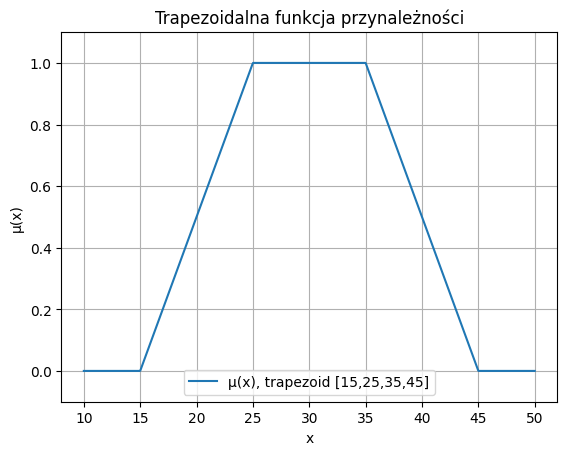

In [ ]:
#definicja funkcji trapezoidalnej w przedziale [a,b,c,d]
def trapezoidal(x, a, b, c, d):
    return np.where(
        (x <= a) | (x >= d), 0,
        np.where(
            (x >= b) & (x <= c), 1,
            np.where((x > a) & (x < b), (x - a) / (b - a),
                     (d - x) / (d - c))
        )
    )

# Dziedzina
x = np.linspace(10, 50, 1000)

# Parametry trapezu
a, b, c, d = 15, 25, 35, 45

# Oblicz wartości funkcji
y = trapezoidal(x, a, b, c, d)

# Wykres
plt.plot(x, y, label=f"μ(x), trapezoid [{a},{b},{c},{d}]")
plt.ylim(-0.1, 1.1)
plt.xlabel("x")
plt.ylabel("μ(x)")
plt.title("Trapezoidalna funkcja przynależności")
plt.grid(True)
plt.legend()
plt.show()

Powyższy przykład zmienia zupełnie paradygmat. Funkcja charakterystyczna, nazywana w tej teori **funkcją przynależności**, przyjmuje nieskończenie wiele wartości od 0 do 1. Możemy to rozumieć różnie. Niektórzy podają wspomnianą "częściową przynależność", która bardzo nie podoba się niektórym matematykom :-) Jednak możemy sobie wyobrazić, iż jest to poziom podobieństwa danej wartości na osi X do określonego pojęcia. Gdy przynależność(podobieństwo) osiąga wartość 1, oznacza pełną zgodność. Gdy przyjmuje wartości niższe, zgodność jest odpowiednio częściowa. Natomiast gdy wartość funkcji przynależności dla elementu osiąga 0, element, zgodnie z klasycznym podejściem, do zbioru nie należy, lub jest zupełnie "niepodobny".

Funkcja charakterystyczna definiuje zbiór klasyczny (które elementy do niego należą, a które nie). Natomiast **funkacja przynalezności**, najczęściej oznaczana za pomocą μ, definiuje **zbiór rozmyty**.

Zwróć uwagę na to, iż w tym wypadku nie ma już dylematu, czy temperatura 24, czy 37 stopni "pasuje" do określenia "ciepła woda". Podejście bardzo elastycznie przypisuje poziom przynalezności mniejszy od 1, ale cały czas dość wysoko, ponieważ te wartości są bardzo podobne do lub bliskie tego określenia. Zupełnie inaczej jest w sytuacji na krańcach zboczy. Temperatura na poziomie 17, czy 43 stopni jest już mało "podobna", uzyskując niskie wartości zdefiniwanej funkcji.

Definiowanie funkcji przynależności jest bardzo elastyczne. Może być określone przez eksperta, w zależności od wymogów sytuacji, lub automatycznie wyznaczone z danych na podstawie np. statystyki.

Jak można zauważyć w powyższym kodzie, definicja funkcji trapezoidalnej, ze względu na konieczność określenia kilku przedziałów, jest co najmniej "pokraczna" i nieporęczna. Stąd bardzo czesto stosuje się inne, bardziej eleganckie formy, które da się łatwiej zapisać matematycznie. Jedną z takich postaci funkcji przynależności w zbiorach rozmytych jest dobrze znana funkcja gaussowska z wierzchołkiem o wartości 1. Do jej stworzenia należy zdefiniować środek oraz szerokość. Dla naszego przykładu "ciepłej wody", mogłaby ona wyglądać następująco:

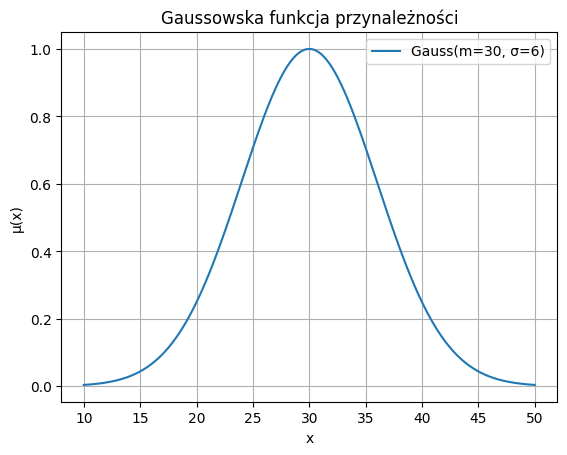

In [ ]:
def gauss(x, m, sigma):
    #Funkcja Gaussa
    return np.exp(-((x - m) ** 2) / (2 * sigma ** 2))

# Dziedzina
x = np.linspace(10, 50, 1000)

# Parametry Gaussa
m, sigma = 30, 6

# Oblicz wartości (m - środek, sigma - "szerokość" opisu)
y = gauss(x, m, sigma)

# Wykres
plt.plot(x, y, label=f"Gauss(m={m}, σ={sigma})")
plt.xlabel("x")
plt.ylabel("μ(x)")
plt.title("Gaussowska funkcja przynależności")
plt.grid(True)
plt.legend()
plt.show()

Zostańmy w naszych testach na tej funkcji, choć istnieje jeszcze bardzo wiele różnych ciekawych matematycznych form. W przypadku zbiorów i systemów rozmytych często wykorzystuje się właśnie wspomniane postaci: trapezoidalną i gaussowską, ale również trójkątną.

Wyznaczmy teraz kilka poziomów przynależności dla powyższej funkcji tak jak zrobilibyśmy to w prostym systemie/aplikacji określającym podobieństwo jednej wartości z danym określeniem:

In [ ]:
p1 = gauss(12, m, sigma)
p2 = gauss(25, m, sigma)
p3 = gauss(32, m, sigma)
p4 = gauss(40, m, sigma)
p5 = gauss(43, m, sigma)

print("Poziomy przynależności:", p1, p2, p3, p4, p5)

Poziomy przynalezności: 0.001533810679324463 0.6065306597126334 0.9231163463866358 0.1353352832366127 0.034047454734599344


Jak można zauważyć, kolejne wartości 12,15,32,40 i 43 znacząco różnią się swoimi poziomami przynależności do naszego zbioru "ciepła woda", gdzie jedynie 25 i 32 posiadają dość wysokie wyniki, zgodnie z przebiegiem wykresu funkcji.

W automatycznym sterowaniu, gdzie istnieje większa liczba różnych parametrów wejściowych, zachodzi potrzeba złożenia kilku określeń ze sobą. Wynika to z konieczności podjęcia decyzji w przypadkach złożonych jak np. "wysoka temperatura i niska wilgotoność". Regułowe systemy rozmyte, jak wspomniano na początku, pozwalają definiować zachowanie systemu za pomocą zrozumiałych dla człowieka definicji, które jak już wiemy, można precyzyjnie opisać za pomocą funkcji przynależności.

Wyobraźmy sobie sytuację, w której tworzymy system sterujący mocą pracy klimatyzatora (sprężarki, grzałki i wentylatora). Celem urządzenia, dla uproszczenia, jest utrzymanie w miarę stałej temperatury oraz wilgotności. Otrzymuje on dwa parametry wejściowe jak temperatura powietrza oraz jego wilgotność. Gdy wilgotność rośnie, a temperatura jest wysoka, to należy zwiększyć moc sprężarki i nawiewu, a grzałka ma być wyłączona. Gdy temperatura jest niska lub w normie, ale rośnie wilgotność, to należy również włączyć grzałkę, aby nie wychłodzić pomieszczenia. Do rozwiązywania tego typu problemów świetnie nadają się regułowe systemy rozmyte i istnieje wiele metod za pomocą których można osiągnąć cel. W tym krótkim ćwiczeniu zastanowimy się jedynie nad detekcją sytuacji złożonej z większej liczby parametrów. Chcielibyśmy mianowicie w sposób rozmyty odpowiedzieć na pytanie, czy jest "ciepło i wilgotno".

Aby rozwiązać to zadanie będziemy potrzebować dwóch zbiorów, które będą zdefiniowane w dwóch różnych przestrzeniach za pomocą znanych nam gaussowskich funkcji przynalezności. Jednym będzie "ciepło"  w kontekście temperatury powietrza w zakresie [-50,50] stopni Celsjusza, a drugim "wilgono" w kontekście procentowej wilgotności, czyli [0,100].

W naszym przypadku niech funkcja przynależności opisująca "ciepło" ma środek równy `m=30` (stopni), a szerokość `sigma=6`. Natomiast funkcja opisująca "wilgotno" ma środek `m=40`, a szerokość `sigma=8`.
Wartości wejściowe naszego prototypu systemu niech reprezentują zmienne `temp` oraz `hum`, odpowiadające temperaturze i wilgotności. Można podobnie rozważać gradajcję typu "bardzo ciepło" lub "niezbyt wilgotno". A zatem sprawdzenie czy jest "ciepło" i "wilgotno" z osobna może wyglądać następująco:

In [ ]:
temp = 23
hum = 30

p1 = gauss(23, 30, 6) #na ile 23 stopnie to "ciepło"
p2 = gauss(28, 40, 8) #na ile 28% wilgotności to "wilgotno"

print('Podobieństwo do określenia "ciepło:"', p1)
print('Podobieństwo do określenia "wilgotno:"', p2)


Podobieństwo do określenia "ciepło:" 0.5063356166481006
Podobieństwo do określenia "wilgotno:" 0.32465246735834974


Zatem widzimy, że w skali [0,1] jest "ciepło" na 0.506, a "wilgotno" na 0.324

Jak wspomniałem, w teorii systemów rozmytych istnieje wiele możliwości łączenia ze sobą koncepcji w regule. Ogólnie służą do tego tzw t-normy i s-normy. Nie będziemy jednak wchodzić w takie szczegóły. Skupimy się na jednej z najporstsrzych możliwości, jakim jest iloczym. Zwróćmy uwagę że bardzo dobrze sprawdzi się on w przypadku łącznika "i" w wyrażeniu. Gdy jedna wartość będzie zerowa lub bliska zeru, to "zamaskuje" ona jakąkolwiek, nawet wysoką drugą wartość. Zobaczmy:

In [ ]:
temp = 23
hum = 30

p1 = gauss(23, 30, 6) #na ile 23 stopnie to "ciepło"
p2 = gauss(28, 40, 8) #na ile 28% wilgotności to "wilgotno"
p1_i_p2 = p1 * p2


print('Podobieństwo do określenia "ciepło":', p1)
print('Podobieństwo do określenia "wilgotno":', p2)
print('Podobieństwo do określenia "ciepło i wilgotno":', p1_i_p2)


Podobieństwo do określenia "ciepło": 0.5063356166481006
Podobieństwo do określenia "wilgotno": 0.32465246735834974
Podobieństwo do określenia "ciepło i wilgotno": 0.16438310725621735


Zachęcam do zabawy. Wprowadzaj różne wartości do zmiennych `temp` oraz `hum` i sprawdź jak się zachowuja wyniki.

Jak sie domyślasz, zamiast iloczynu można zastosować również wybór wartości minimalnej, co dla wielu odsób będzie bardziej intuicyjne. Mnożenie jednak jest szybsze obliczeniowo, stąd jest bardzo często stosowane.

To wszytsko jeśli chodzi o proste zabawy zbiorami i systemami rozmytymi. W drugiej części chciałbym Ci pokazać jak wykorzystać te proste idee zbiorów i systemów rozmytych do stworzenia czegoś znacznie bardziej złożnego. Mianowicie stworzymy klasyfikator, który na podstawie bazy wiedzy (przykładów) będzie potrafił rozpoznać(przypisać do klasy) niewidziany mu wczesniej obiekt.